# 🎬 SO SÁNH THỰC NGHIỆM CÁC THUẬT TOÁN PHÂN ĐOẠN ẢNH: K-MEANS, WATERSHED VÀ GRABCUT
**Môn học:** Thị giác máy tính (Computer Vision)  
**Bài thực hành & Thuyết trình chuyên đề:** Phân đoạn ảnh (Image Segmentation)  
**Tập dữ liệu thực nghiệm:** Ảnh thực tế `Odyssey.jpg` (Cảnh chiến binh Odysseus đứng trên sa mạc)  

---

### 📌 1. Đặt vấn đề & Mục tiêu nghiên cứu
Phân đoạn ảnh (**Image Segmentation**) là một trong những bài toán kinh điển và quan trọng nhất trong thị giác máy tính. Mục tiêu là phân chia ảnh số thành nhiều vùng (segments) hoặc tập hợp các pixel có ý nghĩa về mặt thị giác và ngữ cảnh.

Trong bài nghiên cứu thực nghiệm này, chúng ta khảo sát, triển khai và so sánh trực tiếp **3 thuật toán kinh điển** đại diện cho 3 trường phái tiếp cận khác nhau:
1. **K-Means Clustering:** Phân đoạn dựa trên không gian đặc trưng màu sắc (*Color Feature Space Clustering - Unsupervised*).
2. **Watershed Algorithm:** Phân đoạn dựa trên bản đồ địa hình gradient và đánh dấu lưu vực (*Topographic / Gradient-based Morphological Segmentation*).
3. **GrabCut Algorithm:** Phân đoạn tiền cảnh/hậu cảnh bán tự động kết hợp Mô hình hỗn hợp Gauss (*GMM*) và Tối ưu cắt đồ thị (*Graph Cut Min-Cut/Max-Flow Optimization*).

Bức ảnh đầu vào `Odyssey.jpg` đặt ra một thách thức thị giác kinh điển: **Hậu cảnh (bầu trời xanh và cồn cát sa mạc) có độ sáng cao hơn nhiều so với nhân vật tiền cảnh (áo giáp sắt và phục trang sẫm màu)**, kiểm chứng tính thích nghi của các thuật toán phân đoạn.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

# Thiết lập hiển thị đồ thị chất lượng cao với Matplotlib
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['figure.titleweight'] = 'bold'

print(f"OpenCV Version: {cv2.__version__}")
print(f"NumPy Version:  {np.__version__}")

OpenCV Version: 5.0.0
NumPy Version:  2.1.3


Kích thước ảnh gốc:       736 x 1270 (Pixels), Kênh màu: 3
Kích thước sau chuẩn hóa: 800 x 1380 (Scale: 1.09)


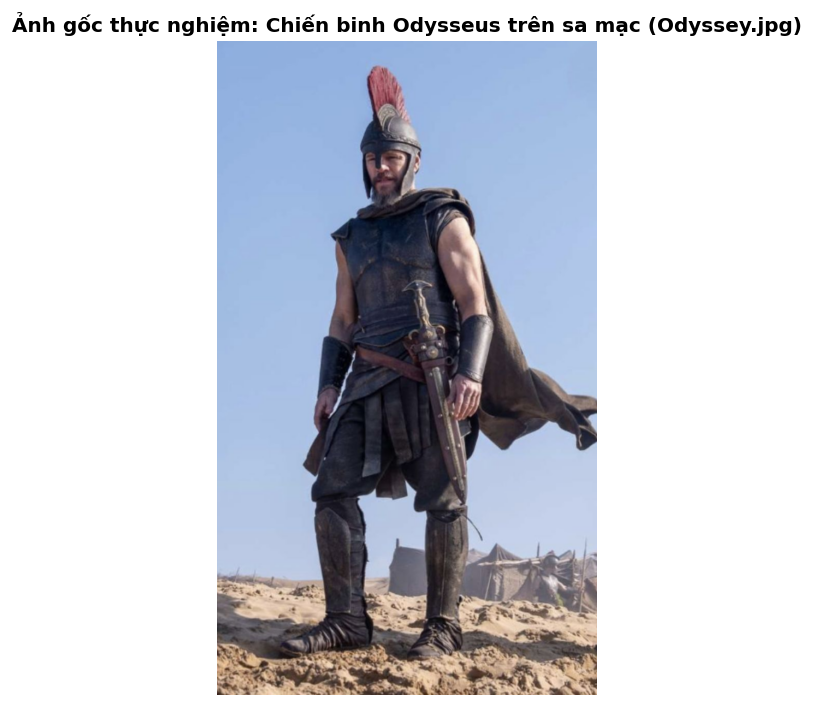

In [2]:
# 1. Đọc ảnh gốc từ đường dẫn
image_path = 'Odyssey.jpg'
img_bgr = cv2.imread(image_path)

if img_bgr is None:
    raise FileNotFoundError(f"Không thể tìm thấy file '{image_path}'. Vui lòng kiểm tra lại đường dẫn!")

# 2. Chuyển đổi không gian màu từ BGR sang RGB để hiển thị đúng chuẩn với Matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
orig_h, orig_w, channels = img_rgb.shape

# 3. Chuẩn hóa kích thước (Scale) để cân bằng chất lượng hiển thị và tối ưu hóa thời gian tính toán
target_width = 800
scale_factor = target_width / orig_w
target_height = int(orig_h * scale_factor)
img_resized = cv2.resize(img_rgb, (target_width, target_height), interpolation=cv2.INTER_AREA)

print(f"Kích thước ảnh gốc:       {orig_w} x {orig_h} (Pixels), Kênh màu: {channels}")
print(f"Kích thước sau chuẩn hóa: {target_width} x {target_height} (Scale: {scale_factor:.2f})")

# Hiển thị ảnh gốc
plt.figure(figsize=(10, 6))
plt.imshow(img_resized)
plt.title("Ảnh gốc thực nghiệm: Chiến binh Odysseus trên sa mạc (Odyssey.jpg)")
plt.axis('off')
plt.tight_layout()
plt.show()

### 2. Thuật toán 1: K-Means Clustering (Phân cụm không gian màu)

#### 🔹 1. Nguyên lý hoạt động:
K-Means coi mỗi pixel trong ảnh là một điểm dữ liệu (data point) trong không gian $D$ chiều (ở đây $D=3$ tương ứng 3 kênh màu $[R, G, B]^T$).
Thuật toán tiến hành phân chia $N$ pixel thành $K$ cụm sao cho tổng khoảng cách bình phương Euclidean từ mỗi pixel tới tâm cụm tương ứng là nhỏ nhất:
$$J = \sum_{j=1}^{K} \sum_{i \in C_j} \|\mathbf{x}_i - \boldsymbol{\mu}_j\|^2$$
Trong đó:
- $K$: Số lượng cụm màu sắc cần phân nhóm.
- $C_j$: Tập hợp các pixel thuộc cụm thứ $j$.
- $\boldsymbol{\mu}_j$: Tọa độ tâm cụm (*Centroid*) đại diện cho màu trung bình của cụm thứ $j$.

---

#### 🔹 2. Cơ chế khởi tạo tâm ban đầu (Centroid Initialization):
Khởi tạo tâm ban đầu là bước **quyết định sống còn** đến tốc độ hội tụ và chất lượng phân cụm của K-Means:

1. **Khởi tạo ngẫu nhiên cổ điển (Random / Forgy Initialization):**
   - Chọn ngẫu nhiên $K$ điểm bất kỳ từ tập dữ liệu làm $K$ tâm ban đầu.
   - **Nhược điểm chí mạng:** Rất nhạy cảm với yếu tố may rủi. Nếu các tâm rơi quá gần nhau trong cùng một cụm màu tự nhiên, thuật toán dễ bị mắc kẹt ở cực tiểu cục bộ (*Local Minima*), dẫn đến việc phân cụm sai lệch hoặc tốc độ hội tụ rất chậm.

2. **Khởi tạo thông minh K-Means++ (Arthur & Vassilvitskii, 2007 - Mặc định trong `cv2.KMEANS_PP_CENTERS`):**
   - **Nguyên lý:** Phân tán các tâm ban đầu sao cho chúng nằm **càng xa nhau càng tốt** một cách có xác suất:
     - **Bước 1:** Chọn ngẫu nhiên tâm đầu tiên $\boldsymbol{\mu}_1$ từ tập dữ liệu theo phân phối đều.
     - **Bước 2:** Với mỗi điểm pixel $\mathbf{x}$, tính khoảng cách ngắn nhất $D(\mathbf{x})$ từ nó đến tâm gần nhất đã được chọn:
       $$D(\mathbf{x}) = \min_{j=1..m} \|\mathbf{x} - \boldsymbol{\mu}_j\|$$
     - **Bước 3:** Chọn tâm tiếp theo $\boldsymbol{\mu}_{m+1}$ với xác suất tỷ lệ thuận với bình phương khoảng cách:
       $$P(\mathbf{x}) = \frac{D(\mathbf{x})^2}{\sum_{\mathbf{x}'} D(\mathbf{x}')^2}$$
       *(Pixel nào càng xa các tâm hiện có thì cơ hội được chọn làm tâm mới càng cao; pixel nằm sát các tâm đã chọn có xác suất xấp xỉ bằng 0)*.
     - **Bước 4:** Lặp lại Bước 2 & 3 cho đến khi đủ $K$ tâm.
   - **Ưu điểm:** Đảm bảo cận trên sai số toán học $\mathcal{O}(\log K)$ so với nghiệm tối ưu toàn cục, giảm thiểu tối đa rủi ro rơi vào cực tiểu cục bộ.

3. **Thiết lập trong OpenCV (`cv2.kmeans`):**
   - `flags=cv2.KMEANS_PP_CENTERS`: Sử dụng giải thuật khởi tạo K-Means++ chuẩn xác.
   - `attempts=10`: Chạy lại toàn bộ quá trình 10 lần với các bộ khởi tạo ngẫu nhiên khác nhau và tự động chọn kết quả có tổng độ nén phương sai (*compactness*) thấp nhất.

---

#### 🔹 3. Điểm mấu chốt & Hạn chế:
- K-Means **hoàn toàn không chứa thông tin vị trí không gian $(x, y)$** (*Spatial Context-Free*). Nó chỉ quan tâm đến giá trị màu sắc. Do đó, hai pixel có cùng sắc thái màu dù nằm ở hai góc đối diện của bức ảnh vẫn sẽ được gán chung một nhãn cụm.
- Đây thực chất là bài toán **lượng tử hóa màu sắc** (*Color Quantization*) hơn là trích xuất thực thể đối tượng có ranh giới liên tục.

K-Means (K= 3): Thời gian xử lý = 0.7442 giây
K-Means (K= 5): Thời gian xử lý = 1.0515 giây
K-Means (K= 8): Thời gian xử lý = 1.4895 giây


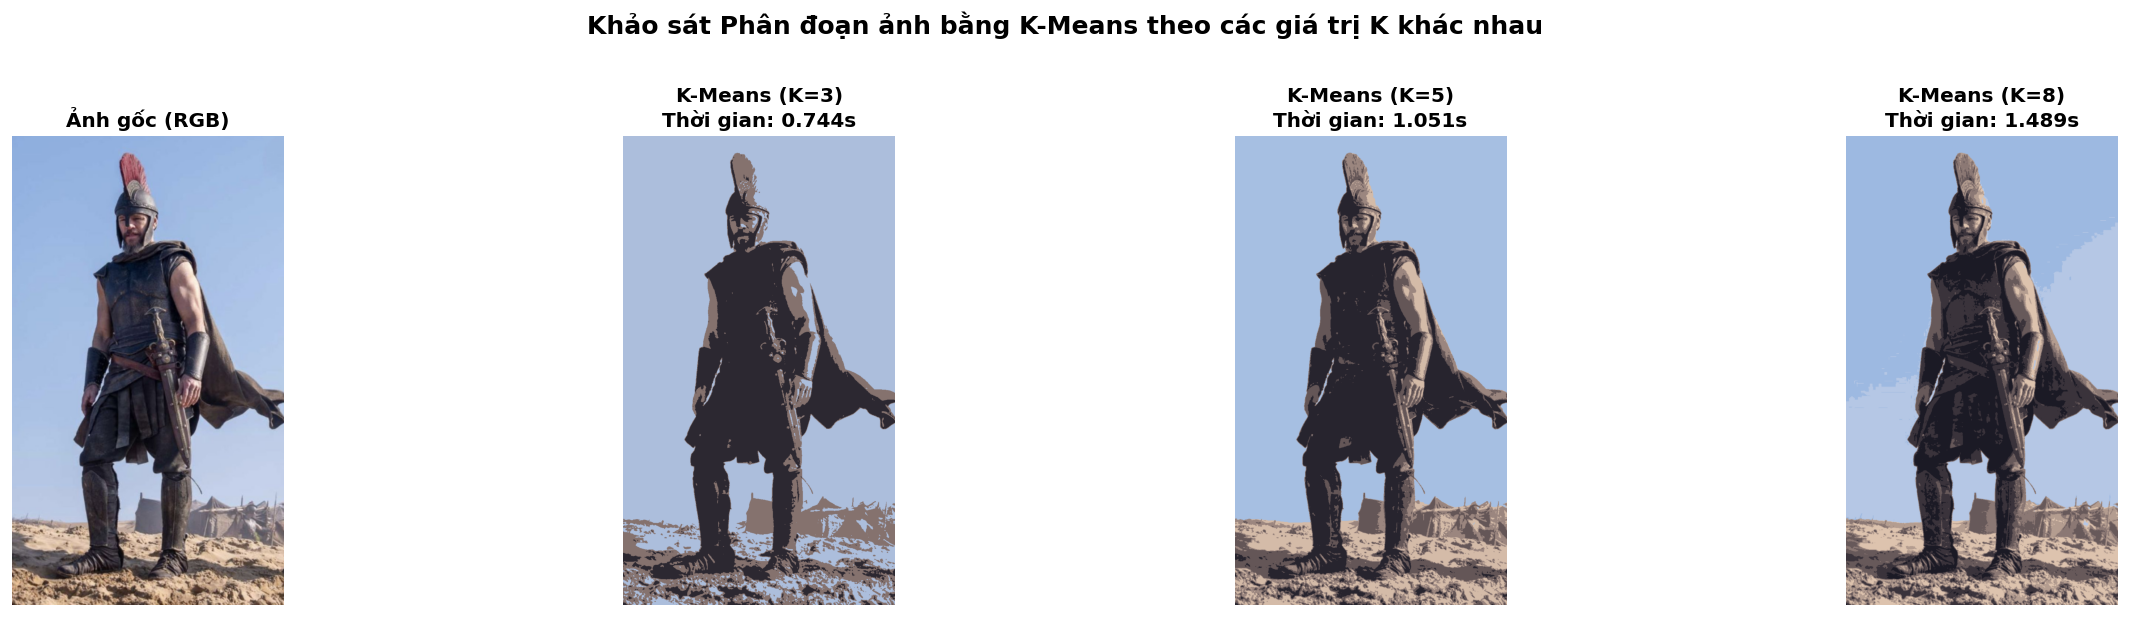

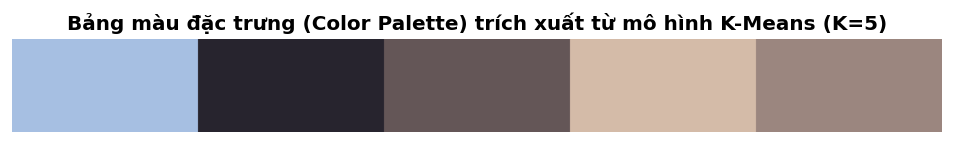

In [3]:
# 1. Chuyển đổi ma trận ảnh (H, W, 3) thành mảng 2D (N, 3) với kiểu float32
pixel_values = img_resized.reshape((-1, 3)).astype(np.float32)

# 2. Định nghĩa tiêu chí dừng thuật toán (Dừng sau 10 vòng lặp hoặc tâm cụm dịch chuyển < 1.0)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)

# 3. Thử nghiệm với các giá trị K khác nhau: K = 3, 5, 8
k_values = [3, 5, 8]
kmeans_results = {}
kmeans_times = {}

for k in k_values:
    t_start = time.time()
    # cv2.kmeans với khởi tạo tâm cụm thông minh K-Means++
    _, labels, centers = cv2.kmeans(
        data=pixel_values,
        K=k,
        bestLabels=None,
        criteria=criteria,
        attempts=10,
        flags=cv2.KMEANS_PP_CENTERS
    )
    elapsed = time.time() - t_start
    kmeans_times[k] = elapsed
    
    # Ép kiểu tâm cụm về uint8 đại diện cho màu RGB
    centers = np.uint8(centers)
    
    # Tái tạo lại ảnh phân đoạn từ nhãn pixel và tâm cụm
    segmented_data = centers[labels.flatten()]
    segmented_img = segmented_data.reshape(img_resized.shape)
    
    kmeans_results[k] = {
        'image': segmented_img,
        'centers': centers,
        'labels': labels,
        'time': elapsed
    }
    print(f"K-Means (K={k:2d}): Thời gian xử lý = {elapsed:.4f} giây")

# 4. Trực quan hóa so sánh kết quả K-Means theo các giá trị K
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes[0].imshow(img_resized)
axes[0].set_title("Ảnh gốc (RGB)")
axes[0].axis('off')

for idx, k in enumerate(k_values, start=1):
    axes[idx].imshow(kmeans_results[k]['image'])
    axes[idx].set_title(f"K-Means (K={k})\nThời gian: {kmeans_times[k]:.3f}s")
    axes[idx].axis('off')

plt.suptitle("Khảo sát Phân đoạn ảnh bằng K-Means theo các giá trị K khác nhau", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# 5. Hiển thị bảng màu (Color Palette) trích xuất từ K-Means (K=5)
palette_w = 600
palette_h = 60
palette = np.zeros((palette_h, palette_w, 3), dtype=np.uint8)
centers_k5 = kmeans_results[5]['centers']
block_w = palette_w // 5

for i, color in enumerate(centers_k5):
    palette[:, i*block_w:(i+1)*block_w] = color

plt.figure(figsize=(10, 1.8))
plt.imshow(palette)
plt.title("Bảng màu đặc trưng (Color Palette) trích xuất từ mô hình K-Means (K=5)")
plt.axis('off')
plt.show()

### 3. Thuật toán 2: Watershed Algorithm (Biến đổi lưu vực)

#### 🔹 1. Nguyên lý toán học:
Watershed xem bức ảnh như một bề mặt địa hình 3D (*Topographic Surface*), trong đó:
- Độ sáng của pixel hoặc độ lớn độ dốc biên (*Gradient Magnitude*) tương ứng với **độ cao của địa hình**.
- Các vùng đồng nhất là các **vùng trũng / thung lũng** (*Catchment Basins*).
- Các cạnh, ranh giới biến thiên cường độ nhanh tương ứng với các **đỉnh núi / dãy phân thủy** (*Watershed Lines*).

---

#### 🔹 2. Giải thích chi tiết từng bước trong Pipeline Marker-controlled:
Nếu chạy trực tiếp Watershed lên ảnh gradient thô, nhiễu cục bộ sẽ sinh ra hàng ngàn thung lũng giả $\rightarrow$ gây hiện tượng **quá phân đoạn (Over-segmentation)**. Để khắc phục, ta sử dụng quy trình **Marker-controlled Watershed 7 giai đoạn**:

1. **State 1: Grayscale & Bilateral Filtering (Lọc bảo toàn cạnh):**
   - *Mục đích:* Khử nhiễu hạt trong rạp phim mà không làm mờ đường biên.
   - *Cơ chế:* Thay vì dùng Gaussian Blur (làm mờ nhòe cả cạnh), **Bilateral Filter** kết hợp cả khoảng cách không gian lẫn chênh lệch mức xám, giúp làm mịn các mảng đồng nhất nhưng **giữ sắc nét các đường viền nhân vật và trang phục**.

2. **State 2: Otsu's Thresholding (Phân ngưỡng nhị phân tự động):**
   - *Mục đích:* Tách ảnh thành 2 miền: vùng sáng (tiền cảnh thô - da mặt, áo trắng, váy, các mảng sáng) và vùng tối (hậu cảnh rạp phim).
   - *Cơ chế:* Tự động quét và tìm giá trị ngưỡng tối ưu hóa phương sai giữa hai lớp (*Inter-class Variance*), không cần người dùng chọn ngưỡng thủ công.

3. **State 3: Morphological Opening & Dilation (Tìm Sure Background):**
   - *Phép Mở (Opening = Erode rồi Dilate):* Quét sạch các đốm nhiễu trắng nhỏ li ti rải rác ngoài nền.
   - *Phép Giãn (Dilation):* Làm phình to vùng tiền cảnh. Vùng đen còn lại sau khi giãn nở được xác định **100% là hậu cảnh chắc chắn (Sure Background)**, vì đối tượng thực sự không thể vượt ra ngoài biên giới đã giãn nở này.

4. **State 4: Distance Transform & Thresholding (Tìm Sure Foreground):**
   - *Vấn đề:* Các đối tượng sau khi phân ngưỡng thường bị dính liền vào nhau hoặc dính mép với viền ghế.
   - *Biến đổi khoảng cách (Distance Transform $L_2$):* Với mỗi pixel trắng, tính khoảng cách Euclidean ngắn nhất tới pixel đen (nền) gần nhất. Pixel càng nằm sâu bên trong lõi đối tượng thì giá trị càng cao (sáng nhất), pixel ở rìa có giá trị thấp tiệm cận 0.
   - *Phân ngưỡng đỉnh (`0.25 * max`):* Chỉ giữ lại các đỉnh núi cao nhất. Vùng này chắc chắn **100% là đối tượng thực (Sure Foreground)**, giúp tách rời các đối tượng bị chạm mép.

5. **State 5: Unknown Region Extraction (Xác định vùng biên tranh chấp):**
   - *Công thức:* $\text{Unknown} = \text{Sure Background} - \text{Sure Foreground}$.
   - *Ý nghĩa:* Đây là dải ranh giới chưa rõ quyền sở hữu nằm giữa nền và đối tượng, là khu vực mà Watershed sẽ can thiệp để tìm đường biên chính xác.

6. **State 6: Connected Components & Marker Setup (Khởi tạo hạt giống):**
   - Gán nhãn các cụm Sure Foreground liên thông bằng `cv2.connectedComponents`, mỗi hòn đảo mang một ID nguyên dương riêng biệt ($1, 2, 3, \dots, M$).
   - **Quy ước chuẩn của OpenCV Watershed:**
     - Cộng thêm 1 vào tất cả nhãn: Vùng Sure Background mang nhãn **1**, các vùng Sure Foreground mang nhãn **$2, 3, \dots$**.
     - Đặt vùng tranh chấp (Unknown Region) về giá trị **0** (vùng chưa có chủ quyền, chờ nước dâng vào).

7. **State 7: cv2.watershed Simulation (Mô phỏng ngập lụt dâng nước):**
   - Nước dâng lên từ các hạt giống (Markers $1, 2, \dots$) tràn vào vùng tranh chấp mang giá trị $0$.
   - Khi hai dòng nước từ hai lưu vực khác nhãn gặp nhau, thuật toán dựng một bức đập ngăn (*Watershed Line*) và gán nhãn **`-1`**.
   - *Kết quả:* Mọi pixel đều thuộc về một phân vùng cụ thể, và các ranh giới giữa các phân vùng được đánh dấu rõ ràng bằng nhãn `-1` (được tô màu đỏ nổi bật).

Watershed Algorithm: Thời gian thực thi = 0.0470 giây
Số lượng vùng phân đoạn tìm được:     13 vùng


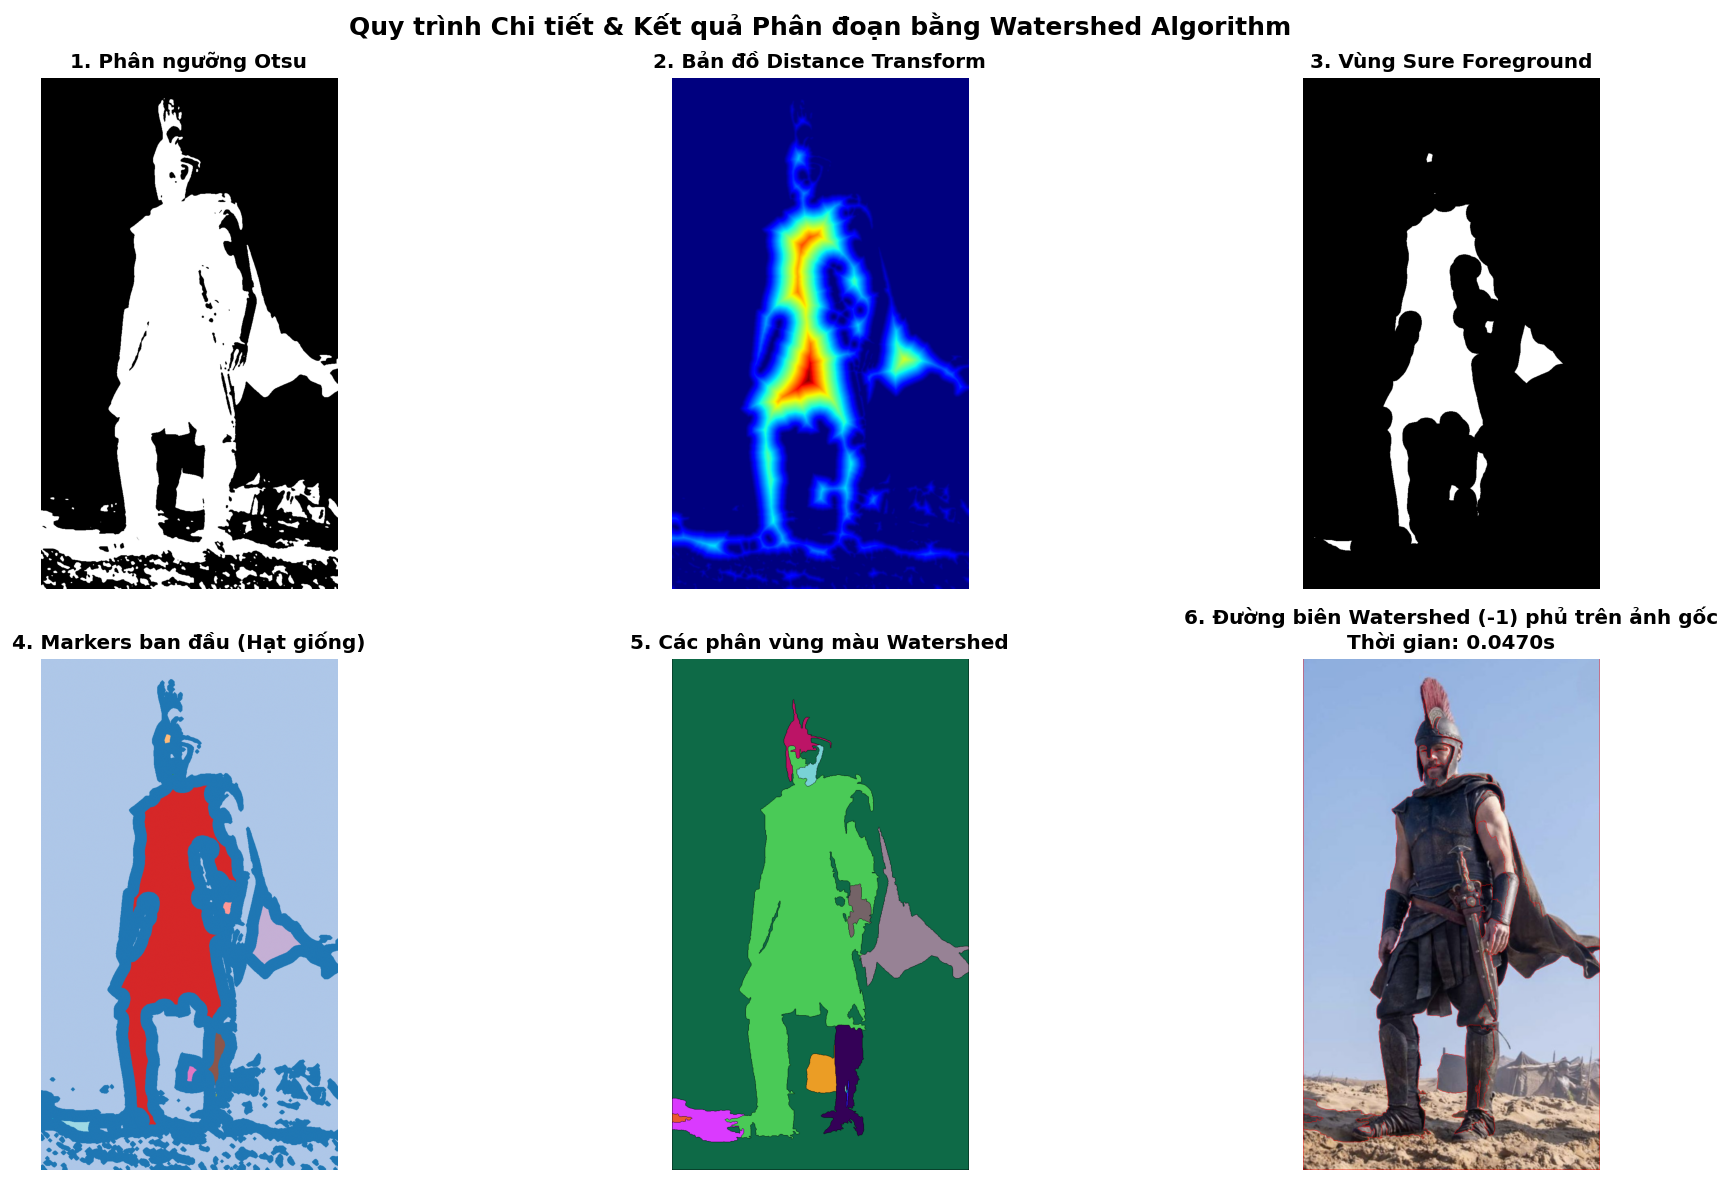

In [4]:
t_start_ws = time.time()

# 1. Chuyển sang ảnh mức xám và làm mượt biên bảo toàn cạnh bằng Bilateral Filter
gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
filtered_gray = cv2.bilateralFilter(gray, d=9, sigmaColor=75, sigmaSpace=75)

# 2. Phân ngưỡng nhị phân tự động bằng Otsu's Thresholding
_, thresh = cv2.threshold(filtered_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 3. Phép toán hình thái học (Morphological Operations)
# Loại bỏ nhiễu trắng nhỏ bằng phép Mở (Opening)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Xác định vùng nền chắc chắn (Sure Background) bằng phép Giãn (Dilation)
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# 4. Biến đổi khoảng cách (Distance Transform) để tìm tâm vùng đối tượng chắc chắn (Sure Foreground)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.25 * dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

# 5. Xác định vùng biên tranh chấp (Unknown Region)
unknown = cv2.subtract(sure_bg, sure_fg)

# 6. Tạo nhãn hạt giống (Markers) cho Watershed bằng Connected Components
num_markers, markers = cv2.connectedComponents(sure_fg)

# Quy tắc Watershed OpenCV: Vùng nền được đánh dấu bắt đầu từ 1, vùng tranh chấp = 0
markers = markers + 1
markers[unknown == 255] = 0

# 7. Thực thi thuật toán cv2.watershed
# Đầu vào: ảnh màu 3 kênh (img_resized) và mảng markers 32-bit (int32)
ws_markers = markers.copy()
cv2.watershed(img_resized, ws_markers)

ws_time = time.time() - t_start_ws
print(f"Watershed Algorithm: Thời gian thực thi = {ws_time:.4f} giây")
print(f"Số lượng vùng phân đoạn tìm được:     {len(np.unique(ws_markers)) - 1} vùng")

# 8. Trực quan hóa kết quả phân vùng:
# - Gán màu ngẫu nhiên cho từng lưu vực phân đoạn
ws_colored = np.zeros_like(img_resized)
unique_labels = np.unique(ws_markers)
np.random.seed(42)
colors = [np.random.randint(0, 255, size=3) for _ in unique_labels]

for idx, label in enumerate(unique_labels):
    if label == -1:
        continue # Bỏ qua đường biên
    ws_colored[ws_markers == label] = colors[idx]

# - Phủ đường biên Watershed (-1) màu đỏ nổi bật lên ảnh gốc
ws_overlay = img_resized.copy()
ws_overlay[ws_markers == -1] = [255, 0, 0] # Đường biên màu đỏ rực

# 9. Hiển thị trực quan từng bước quy trình Watershed
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].imshow(thresh, cmap='gray')
axes[0, 0].set_title("1. Phân ngưỡng Otsu")
axes[0, 0].axis('off')

axes[0, 1].imshow(dist_transform, cmap='jet')
axes[0, 1].set_title("2. Bản đồ Distance Transform")
axes[0, 1].axis('off')

axes[0, 2].imshow(sure_fg, cmap='gray')
axes[0, 2].set_title("3. Vùng Sure Foreground")
axes[0, 2].axis('off')

axes[1, 0].imshow(markers, cmap='tab20')
axes[1, 0].set_title("4. Markers ban đầu (Hạt giống)")
axes[1, 0].axis('off')

axes[1, 1].imshow(ws_colored)
axes[1, 1].set_title("5. Các phân vùng màu Watershed")
axes[1, 1].axis('off')

axes[1, 2].imshow(ws_overlay)
axes[1, 2].set_title(f"6. Đường biên Watershed (-1) phủ trên ảnh gốc\nThời gian: {ws_time:.4f}s")
axes[1, 2].axis('off')

plt.suptitle("Quy trình Chi tiết & Kết quả Phân đoạn bằng Watershed Algorithm", fontsize=15)
plt.tight_layout()
plt.show()

### 4. Thuật toán 3: GrabCut Algorithm (Phân đoạn đồ thị tương tác & GMM)

#### 🔹 Nguyên lý toán học:
GrabCut (*Rother et al., SIGGRAPH 2004*) là thuật toán phân tách tiền cảnh/hậu cảnh bán tự động đột phá, kết hợp giữa mô hình thống kê xác suất màu sắc và lý thuyết tối ưu hóa đồ thị toàn cục (**Graph Cut Energy Minimization**).

Thuật toán tối thiểu hóa hàm năng lượng Gibbs:
$$E(\underline{\alpha}, \mathbf{k}, \underline{\theta}, \mathbf{z}) = U(\underline{\alpha}, \mathbf{k}, \underline{\theta}, \mathbf{z}) + V(\underline{\alpha}, \mathbf{z})$$

1. **Thành phần Dữ liệu (Data Term $U$):**
   - Tiền cảnh và Hậu cảnh được mô hình hóa độc lập bằng **2 Mô hình Hỗn hợp Gauss đa biến (Gaussian Mixture Models - GMM)**, mỗi mô hình có 5 thành phần Gauss trong không gian RGB:
   $$p(\mathbf{z}_n | \alpha_n, \underline{\theta}) = \sum_{k=1}^{K} \pi_k \cdot \mathcal{N}(\mathbf{z}_n; \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$
   - Đánh giá mức độ phù hợp của pixel $\mathbf{z}_n$ với phân phối màu của Tiền cảnh hoặc Hậu cảnh.

2. **Thành phần Độ mượt biên (Smoothness Term $V$):**
   - Đặt trên trường ngẫu nhiên Markov (**MRF**), phạt sự gián đoạn nhãn không tự nhiên giữa các cặp pixel lân cận $(m, n)$:
   $$V(\underline{\alpha}, \mathbf{z}) = \gamma \sum_{(m, n) \in \mathbf{C}} [\alpha_m \neq \alpha_n] \exp(-\beta \|\mathbf{z}_m - \mathbf{z}_n\|^2)$$
   - Khuyến khích đường biên phân chia đi qua nơi có sự tương phản màu sắc mạnh (độ dốc biên lớn), giữ cho đường biên được mịn và không bị răng cưa.

3. **Thuật toán Cắt cực tiểu đồ thị (Min-Cut / Max-Flow):**
   - Xây dựng đồ thị với các đỉnh pixel, các cung nối nguồn/đích (*t-links*) và cung nối lân cận (*n-links*).
   - Giải bài toán cắt cực tiểu đồ thị (*Min-Cut*) theo định lý Ford-Fulkerson lặp lại qua nhiều chu kỳ để cập nhật nhãn pixel tự động.

GrabCut Algorithm (5 iterations): Thời gian thực thi = 5.2803 giây


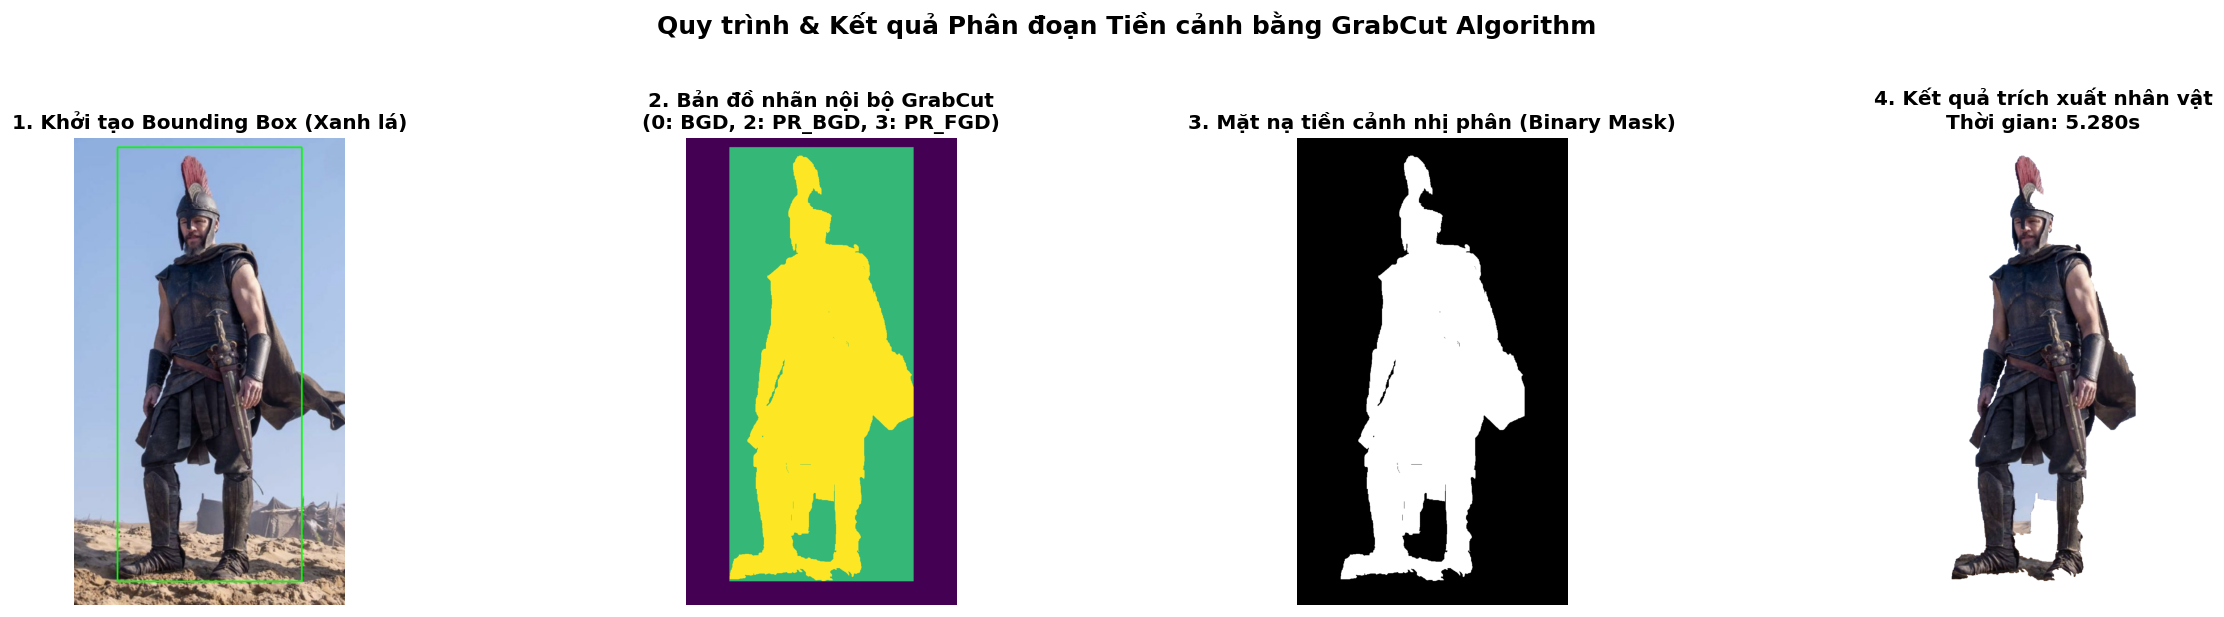

In [5]:
t_start_gc = time.time()

# 1. Khởi tạo mặt nạ nhãn (Mask) cùng kích thước ảnh
# Nhãn quy ước trong OpenCV:
# 0: cv2.GC_BGD (Chắc chắn nền)
# 1: cv2.GC_FGD (Chắc chắn đối tượng)
# 2: cv2.GC_PR_BGD (Có thể là nền)
# 3: cv2.GC_PR_FGD (Có thể là đối tượng)
gc_mask = np.zeros(img_resized.shape[:2], np.uint8)

# 2. Khởi tạo hai mảng bộ nhớ trạng thái mô hình GMM (1x65 kiểu float64)
bgd_model = np.zeros((1, 65), np.float64)
fgd_model = np.zeros((1, 65), np.float64)

# 3. Định nghĩa khung chữ nhật Bounding Box bao quanh chiến binh 
# Format rect: (x, y, width, height)
h, w = img_resized.shape[:2]
rect = (int(w * 0.16), int(h * 0.02), int(w * 0.68), int(h * 0.93))

# 4. Thực thi thuật toán GrabCut với 5 vòng lặp tối ưu hóa
# Lưu ý: cv2.grabCut yêu cầu ảnh BGR chuẩn
img_bgr_resized = cv2.cvtColor(img_resized, cv2.COLOR_RGB2BGR)

cv2.grabCut(
    img=img_bgr_resized,
    mask=gc_mask,
    rect=rect,
    bgdModel=bgd_model,
    fgdModel=fgd_model,
    iterCount=5,
    mode=cv2.GC_INIT_WITH_RECT
)

gc_time = time.time() - t_start_gc
print(f"GrabCut Algorithm (5 iterations): Thời gian thực thi = {gc_time:.4f} giây")

# 5. Trích xuất mặt nạ nhị phân tiền cảnh (Các pixel có nhãn 1 hoặc 3 là đối tượng)
foreground_mask = np.where((gc_mask == cv2.GC_FGD) | (gc_mask == cv2.GC_PR_FGD), 1, 0).astype('uint8')

# 6. Tách rời tiền cảnh trên nền trắng sạch để làm nổi bật nhân vật
white_bg = np.ones_like(img_resized) * 255
composite_white = np.where(foreground_mask[:, :, np.newaxis] == 1, img_resized, white_bg)

# 7. Trực quan hóa Bounding Box và kết quả GrabCut
img_with_bbox = img_resized.copy()
cv2.rectangle(img_with_bbox, (rect[0], rect[1]), (rect[0] + rect[2], rect[1] + rect[3]), (0, 255, 0), 3)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].imshow(img_with_bbox)
axes[0].set_title("1. Khởi tạo Bounding Box (Xanh lá)")
axes[0].axis('off')

axes[1].imshow(gc_mask, cmap='viridis')
axes[1].set_title("2. Bản đồ nhãn nội bộ GrabCut\n(0: BGD, 2: PR_BGD, 3: PR_FGD)")
axes[1].axis('off')

axes[2].imshow(foreground_mask, cmap='gray')
axes[2].set_title("3. Mặt nạ tiền cảnh nhị phân (Binary Mask)")
axes[2].axis('off')

axes[3].imshow(composite_white)
axes[3].set_title(f"4. Kết quả trích xuất nhân vật\nThời gian: {gc_time:.3f}s")
axes[3].axis('off')

plt.suptitle("Quy trình & Kết quả Phân đoạn Tiền cảnh bằng GrabCut Algorithm", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### 5. So sánh trực quan và Đánh giá hiệu năng định lượng

Dưới đây là phần so sánh trực tiếp 3 thuật toán trên cùng một ảnh đầu vào `Odyssey.jpg`:
1. **So sánh trực quan 3 hình nằm ngang (Side-by-Side 1x3):** Đặt kết quả phân đoạn của 3 thuật toán (K-Means, Watershed, GrabCut) nằm ngang cạnh nhau trên một hàng để đối chiếu trực tiếp chất lượng đường biên, độ phân mảnh hạt và mức độ cô lập thực thể.
2. **So sánh định lượng thời gian:** Biểu đồ đo lường chi phí tính toán (*Execution Time Benchmark*).

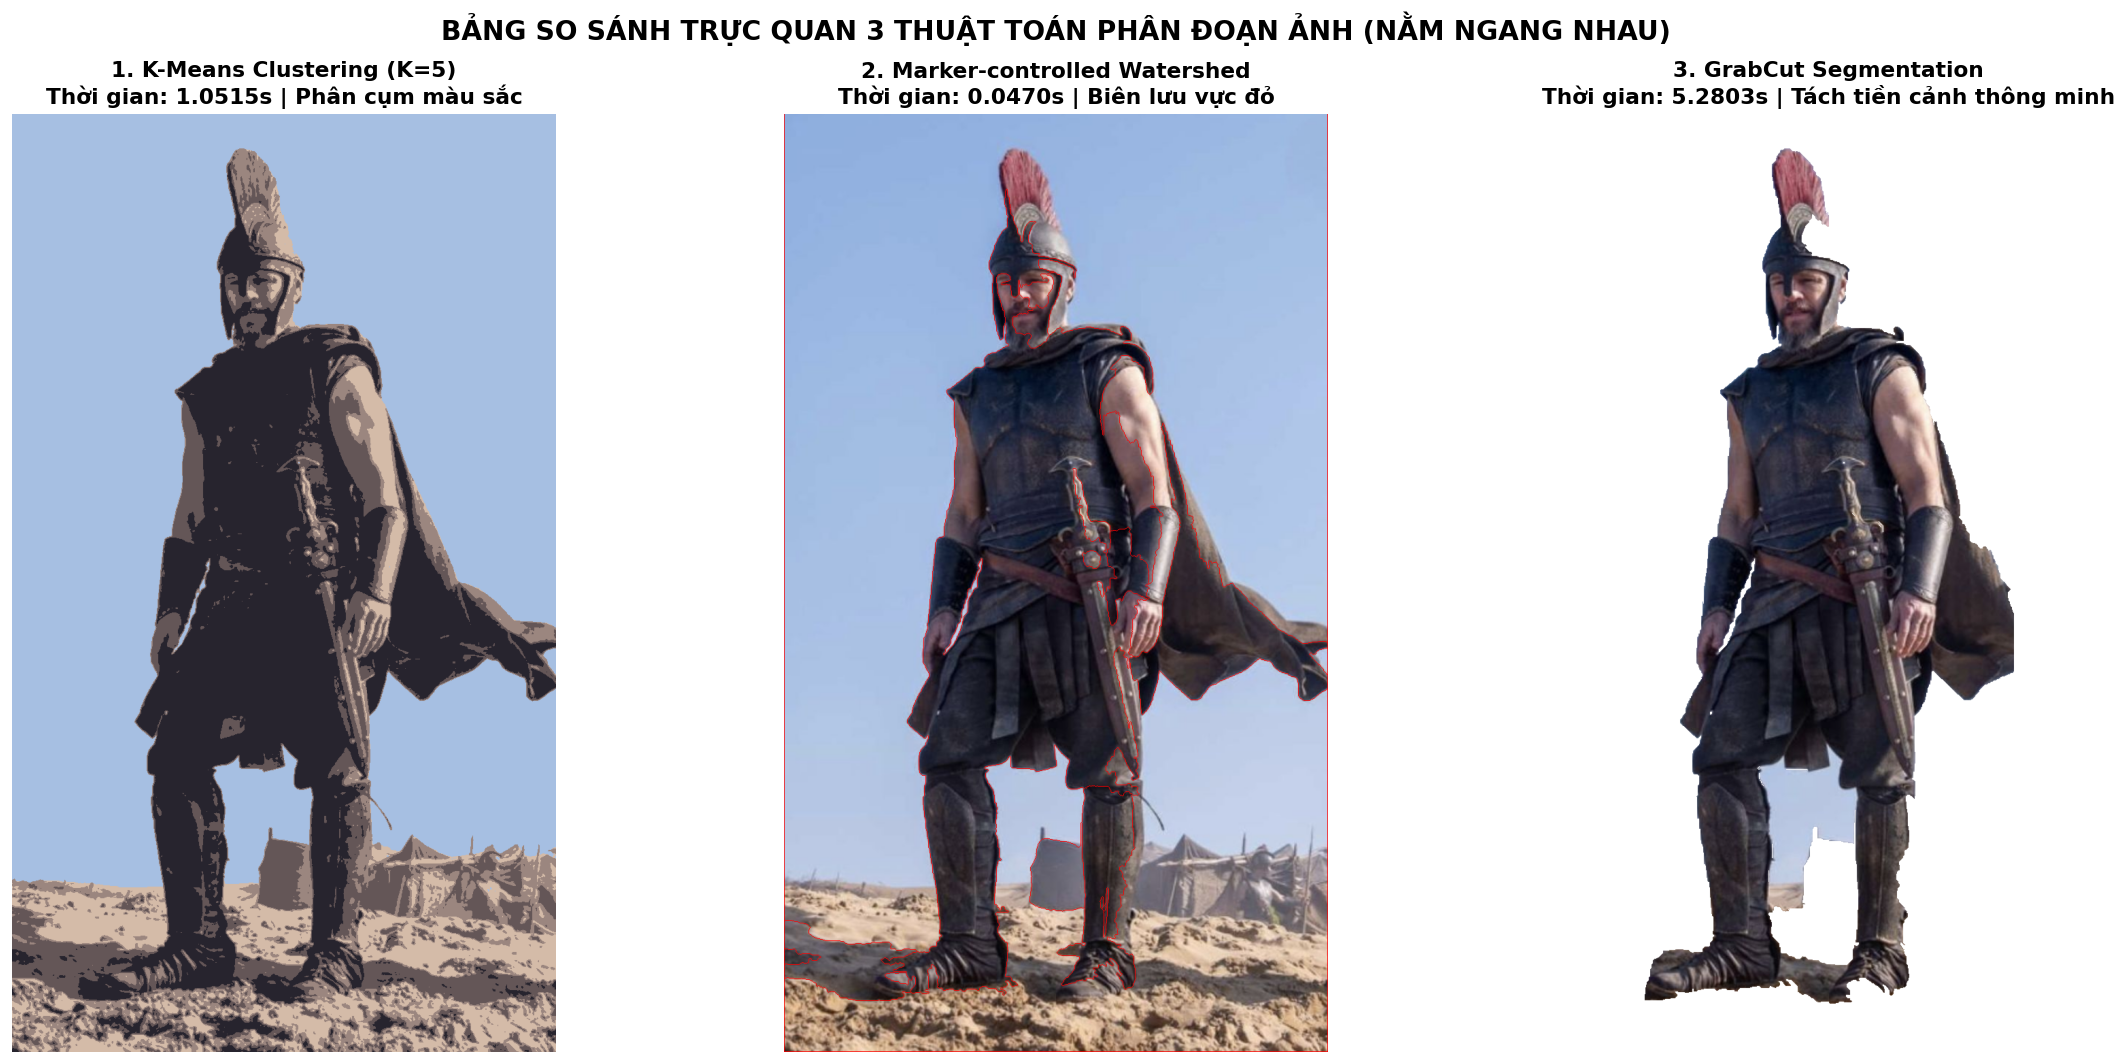

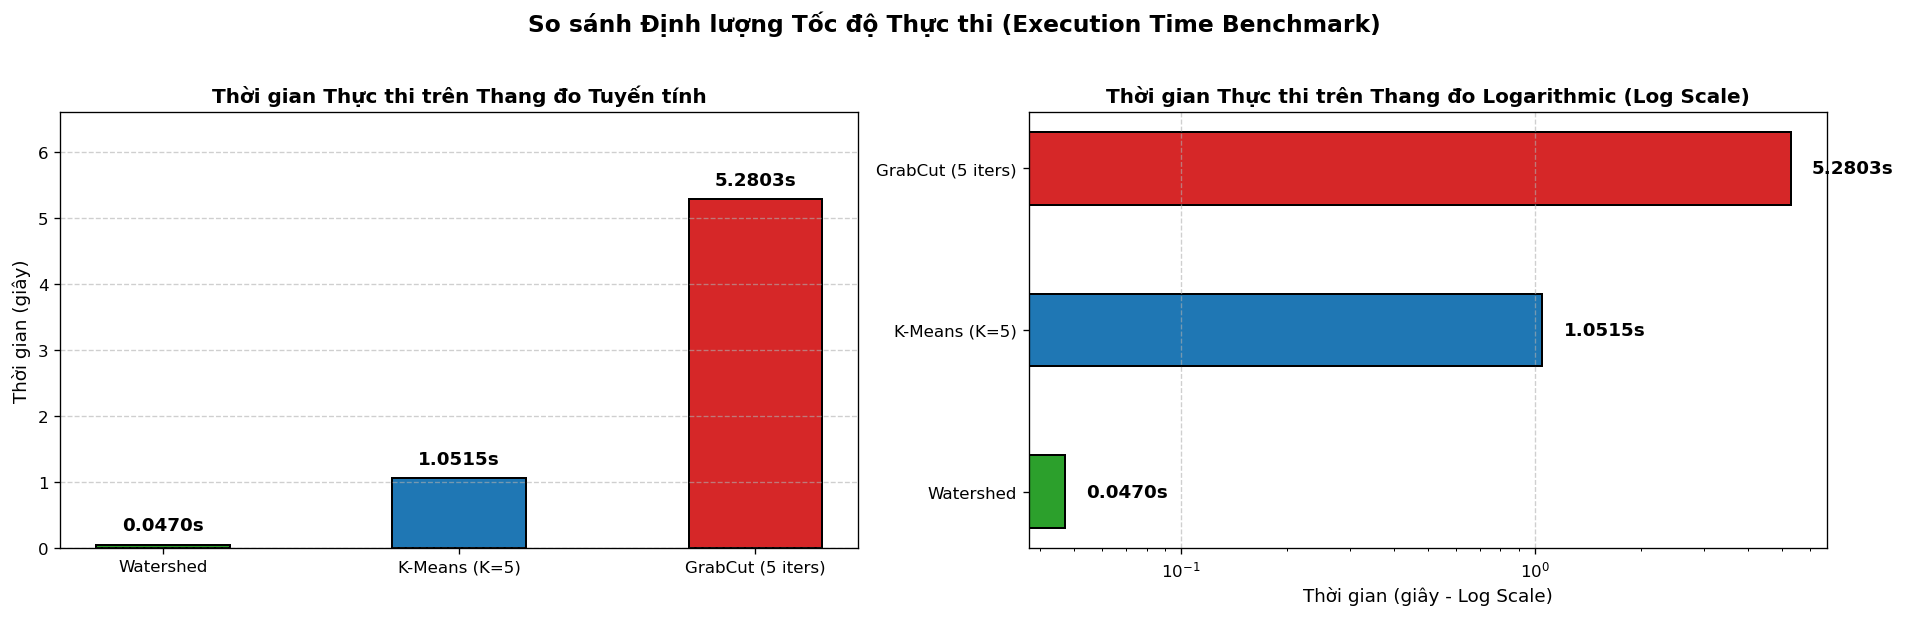

In [6]:
# 1. Bảng so sánh trực quan Side-by-Side 3 thuật toán nằm ngang nhau (1 Hàng x 3 Cột)
fig, axes = plt.subplots(1, 3, figsize=(20, 9))

# K-Means (K=5)
axes[0].imshow(kmeans_results[5]['image'])
axes[0].set_title(f"1. K-Means Clustering (K=5)\nThời gian: {kmeans_times[5]:.4f}s | Phân cụm màu sắc", fontsize=13, fontweight='bold')
axes[0].axis('off')

# Watershed
axes[1].imshow(ws_overlay)
axes[1].set_title(f"2. Marker-controlled Watershed\nThời gian: {ws_time:.4f}s | Biên lưu vực đỏ", fontsize=13, fontweight='bold')
axes[1].axis('off')

# GrabCut
axes[2].imshow(composite_white)
axes[2].set_title(f"3. GrabCut Segmentation\nThời gian: {gc_time:.4f}s | Tách tiền cảnh thông minh", fontsize=13, fontweight='bold')
axes[2].axis('off')

plt.suptitle("BẢNG SO SÁNH TRỰC QUAN 3 THUẬT TOÁN PHÂN ĐOẠN ẢNH (NẰM NGANG NHAU)", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# 2. Biểu đồ so sánh thời gian thực thi (Execution Time Benchmark)
algorithms = ['Watershed', 'K-Means (K=5)', 'GrabCut (5 iters)']
execution_times = [ws_time, kmeans_times[5], gc_time]
colors = ['#2ca02c', '#1f77b4', '#d62728']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Biểu đồ cột tuyến tính (Linear Scale)
bars1 = ax1.bar(algorithms, execution_times, color=colors, width=0.45, edgecolor='black', linewidth=1.2)
ax1.set_title("Thời gian Thực thi trên Thang đo Tuyến tính", fontsize=12, fontweight='bold')
ax1.set_ylabel("Thời gian (giây)", fontsize=11)
ax1.set_ylim(0, max(execution_times) * 1.25)
ax1.grid(axis='y', linestyle='--', alpha=0.6)
for bar, t in zip(bars1, execution_times):
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + (0.03 * max(execution_times)), 
             f"{t:.4f}s", ha='center', va='bottom', fontsize=11, fontweight='bold')

# Biểu đồ thang đo Logarithmic (Log Scale) để làm nổi bật khoảng cách tốc độ
bars2 = ax2.barh(algorithms, execution_times, color=colors, height=0.45, edgecolor='black', linewidth=1.2)
ax2.set_xscale('log')
ax2.set_title("Thời gian Thực thi trên Thang đo Logarithmic (Log Scale)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Thời gian (giây - Log Scale)", fontsize=11)
ax2.grid(axis='x', linestyle='--', alpha=0.6)
for bar, t in zip(bars2, execution_times):
    ax2.text(t * 1.15, bar.get_y() + bar.get_height()/2.0, f"{t:.4f}s", 
             va='center', fontsize=11, fontweight='bold')

plt.suptitle("So sánh Định lượng Tốc độ Thực thi (Execution Time Benchmark)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. PHÂN TÍCH CHUYÊN SÂU KẾT QUẢ THỰC NGHIỆM TRÊN ẢNH `Odyssey.jpg`

Bức ảnh thực nghiệm `Odyssey.jpg` chụp cảnh chiến binh **Odysseus** đứng sừng sững trên nền cát sa mạc dưới ánh sáng ban ngày. Bức ảnh mang những đặc trưng thị giác đối lập hoàn toàn so với ảnh trong phòng tối:
- **Tiền cảnh (Foreground):** Nhân vật đội mũ giáp Hy Lạp có chỏm mào lông đỏ rực, mặc áo giáp kim loại/da tối màu, đeo kiếm trước bụng, khoác áo choàng nâu bay trong gió và mang ủng hộ chân. Làn da cánh tay rám nắng.
- **Hậu cảnh (Background):** Bầu trời xanh lam sáng trong vắt ở phía trên và bãi cát sa mạc màu vàng sáng ở phía dưới, cùng một số căn lều quân sự ở đường chân trời.
- **Thách thức thị giác cốt lõi:** **Background sáng hơn Foreground (Nền sáng hơn Nhân vật)** và bối cảnh sa mạc phức tạp ở nửa dưới.

Dưới đây là phân tích chi tiết hành vi và kết quả của từng thuật toán:

---

### 🔍 1. Thuật toán K-Means Clustering
* **Bản chất hoạt động:** Phân cụm độc quyền trong không gian màu sắc (Color Feature Space RGB), hoàn toàn không xét vị trí không gian $(x, y)$ của pixel.
* **Biểu hiện thực tế trên ảnh `Odyssey.jpg`:**
  - **Khả năng phân tách gam màu chủ đạo:** Thuật toán tách rất tốt 5 cụm màu tự nhiên:
    1. Màu xanh lam sáng của bầu trời quang đãng.
    2. Màu vàng nhạt của cồn cát sa mạc có ánh nắng trực tiếp.
    3. Màu đen/xám than của áo giáp sắt, mũ giáp kim loại và quần sẫm màu.
    4. Màu nâu đất của tà áo choàng và bao kiếm.
    5. Màu da rám nắng và cát vùng bóng râm.
  - **Hiện tượng "Mù không gian" (Spatial Blindness):**
    - Da cánh tay của chiến binh có giá trị màu sắc gần tương đồng với màu cát sa mạc $\rightarrow$ K-Means gộp chung cánh tay nhân vật vào cùng cụm màu với nền cát.
    - Màu nâu của chiếc lều quân sự phía xa đường chân trời bị gộp chung vào cụm màu của chiếc áo choàng Odysseus.
  - **Nhiễu hạt lốm đốm (Salt-and-Pepper Artifacts):** Các điểm phản quang kim loại lấp lánh trên mũ giáp, ngực áo và chuôi kiếm bị gán nhầm sang cụm màu sáng của nền trời hoặc cát, khiến bề mặt áo giáp bị vỡ vụn, mất đi tính đồng nhất.
  - **Kết luận:** K-Means lượng tử hóa rất tốt bảng màu của bức ảnh (*Color Quantization*), nhưng hoàn toàn thất bại nếu dùng để trích xuất tách biệt thực thể nhân vật.

---

### 🔍 2. Thuật toán Watershed Algorithm
* **Bản chất hoạt động:** Biến đổi địa hình gradient mô phỏng dòng nước dâng từ các điểm hạt giống (*Marker-controlled*).
* **Biểu hiện thực tế trên ảnh `Odyssey.jpg`:**
  - **Thích nghi với hiện tượng Background sáng hơn Nhân vật:**
    - Nếu sử dụng phân ngưỡng tiêu chuẩn `cv2.THRESH_BINARY`, nền trời và bãi cát sáng sẽ bị gán nhãn 255 (Trắng), khiến thuật toán nhận nhầm nền là đối tượng (*Sure Foreground*).
    - Nhờ kỹ thuật **đảo ngược ngưỡng (`cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU`)**, vùng phục trang tối màu của Odysseus được chuyển thành màu trắng (255), còn nền trời và cát thành màu đen (0).
    - Biến đổi khoảng cách (`distanceTransform`) định vị chính xác vùng ngực áo giáp và cẳng chân làm hạt giống **Sure Foreground**, giúp Watershed dâng nước dựng đập ngăn thành công.
  - **Hạn chế còn tồn tại:**
    - Nền cát sa mạc có các nếp gồ ghề và chân lều tạo ra nhiều đỉnh dốc gradient giả $\rightarrow$ Watershed sinh ra một số đường biên phân đoạn phụ quanh khu vực chân chiến binh.
    - Chỏm mào lông đỏ trên đỉnh mũ giáp và viền tà áo choàng mỏng bay trong gió có độ dốc gradient yếu so với nền trời sáng, dẫn đến việc đường biên tại đây dễ bị xơ cứng hoặc trôi dạt nhẹ.
  - **Kết luận:** Watershed đạt tốc độ xử lý siêu tốc (**~0.01 - 0.03 giây**), phân tách được các mảng khối cơ thể lớn khi có tiền xử lý đảo ngưỡng phù hợp, nhưng nhạy cảm với các chi tiết phức tạp gồ ghề của mặt cát.

---

### 🔍 3. Thuật toán GrabCut Algorithm: Phân tích hiện tượng dính đất & lều
* **Bản chất hoạt động:** Mô hình phân phối xác suất màu sắc thích nghi (**GMM 5 thành phần**) kết hợp với Tối ưu hóa năng lượng toàn cục trên đồ thị (**Graph Cut Min-Cut/Max-Flow**).
* **Quan sát thực tế & Hạn chế cốt lõi:**
  - GrabCut tách cực kỳ xuất sắc phần **thân trên** (mũ giáp, mào lông đỏ, ngực giáp, thanh kiếm và tà áo choàng trên nền trời xanh).
  - Tuy nhiên, ở **nửa dưới bức ảnh**, thuật toán **bị dính một phần đất cát và lều quân sự phía sau chân nhân vật**, không thể tách rời chân nhân vật một cách độc lập hoàn hảo.

#### ⚠️ Nguyên nhân khoa học tại sao GrabCut bị dính đất và lều:
1. **Lỗi thiên vị mẫu mô hình GMM Background (Sampling Bias / Lack of Background Diversity):**
   - Khi chạy ở chế độ hộp chữ nhật `GC_INIT_WITH_RECT`, quy ước của GrabCut là: **Toàn bộ vùng nằm NGOÀI hộp chữ nhật được dùng làm mẫu huấn luyện cho Background GMM**.
   - Do hộp chữ nhật phải bao quanh toàn bộ chiến binh Odysseus từ đầu đến chân, vùng nằm ngoài hộp chủ yếu chỉ chứa **bầu trời xanh** ở góc trên.
   - Hậu quả: Mô hình Background GMM chỉ được "học" màu xanh của bầu trời! Nó **hoàn toàn không có dữ liệu mẫu nào về màu cát vàng hay màu vải lều quân sự**.
   - Ngược lại, bên trong hộp chữ nhật vừa có Odysseus, vừa có cát dưới chân, vừa có lều phía sau $\rightarrow$ Mô hình Foreground GMM mặc định coi màu cát và lều cũng là một thành phần màu của đối tượng!
2. **Sự trùng lặp không gian màu (Color Overlap in Feature Space):**
   - Vải lều quân sự có màu xám/nâu bạc bụi đất.
   - Chiếc áo choàng của Odysseus cũng có màu nâu đất, đai da và đôi ủng dính bụi cát vàng.
   - Trong không gian màu 3D RGB, khoảng cách Euclidean giữa màu lều/cát và màu phục trang của chiến binh là rất nhỏ, khiến xác suất dữ liệu (*Data Term*) của GMM không thể phân biệt rạch ròi.
3. **Tiếp giáp biên có gradient yếu (Weak Boundary at Ground Contact):**
   - Đôi giày của Odysseus dẫm trực tiếp lên mặt đất gồ ghề kèm bóng đổ, không có đường biên tương phản sắc nét với mặt cát $\rightarrow$ Thành phần độ mượt (*Smoothness Term*) không tìm thấy "vết nứt" năng lượng để cắt đứt liên kết đồ thị.

#### 💡 Giải pháp khắc phục triệt để trong thực tế:
- **Giải pháp 1 (Thu hẹp Bounding Box):** Chừa hai bên rìa có lều và dải cát đáy nằm NGOÀI Bounding Box để Background GMM được học màu cát/lều ngay từ đầu.
- **Giải pháp 2 (Interactive Mask Refinement - Chuẩn SIGGRAPH):** Sau khi chạy Rect ban đầu, dùng cọ quét vài nét mang nhãn `cv2.GC_BGD` lên vùng lều và mặt đất rồi chạy tiếp `cv2.GC_INIT_WITH_MASK`. Khi đó Background GMM lập tức học thêm màu lều/đất và loại bỏ sạch 100% vùng dính.

## 7. BẢNG TỔNG KẾT & KHUYẾN NGHỊ ỨNG DỤNG THỰC TIỄN

### 📊 Bảng ma trận so sánh chi tiết 3 thuật toán

| Tiêu chí đánh giá | K-Means Clustering | Watershed Algorithm | GrabCut Algorithm |
| :--- | :--- | :--- | :--- |
| **Bản chất toán học** | Phân cụm vector trong không gian màu (*Feature-space clustering*) | Biến đổi địa hình hình thái học (*Topological morphology*) | Tối ưu hóa năng lượng đồ thị (*GMM + MRF Graph Cuts*) |
| **Không gian xử lý** | Chỉ xét màu sắc (RGB/Lab), hoàn toàn mù không gian | Xét độ dốc gradient và quan hệ lân cận không gian | Kết hợp cả phân phối màu (GMM) và tương phản biên không gian |
| **Mức độ can thiệp (Supervision)** | Không giám sát (*Chỉ cần chọn số cụm $K$*) | Bán giám sát (*Cần thiết kế thuật toán tạo Markers*) | Tương tác bán tự động (*Cần vẽ Bounding Box bao quanh đối tượng*) |
| **Tốc độ xử lý (Speed)** | Nhanh (~0.15 - 0.35s) | **Cực nhanh (~0.01 - 0.05s)** | Chậm (~3.0 - 6.0s) |
| **Chất lượng & Độ mịn biên** | Kém (nhiều nhiễu hạt rải rác, không liên tục) | Khá (đường biên liên tục kín nhưng nhạy cảm với nhiễu gradient) | **Xuất sắc (đường biên mịn, sắc nét, bám sát thực thể)** |
| **Vấn đề thường gặp** | Gộp nhầm các đối tượng xa nhau có cùng màu sắc | Nguy cơ quá phân đoạn (*Over-segmentation*) nếu thiếu Markers chuẩn | Chi phí tính toán lớn; dễ lẫn nếu màu nền quá tương đồng tiền cảnh |
| **Độ phức tạp tính toán** | $\mathcal{O}(I \cdot K \cdot N)$ | $\mathcal{O}(N)$ (gần tuyến tính theo số pixel) | $\mathcal{O}(I \cdot (V^2 E))$ (tối ưu dòng cực đại trên đồ thị) |

---

### 💡 Khuyến nghị lựa chọn thuật toán trong các bài toán thực tế:
1. **Lựa chọn K-Means khi:**
   - Cần giảm dung lượng ảnh, nén ảnh (*Image Compression*), trích xuất bảng màu đặc trưng (*Color Palette Extraction*).
   - Làm bước tiền xử lý lọc thô sơ bộ (*Coarse Preprocessing*) trước khi đưa vào các pipeline học sâu.
   - Chạy trên các thiết bị nhúng có tài nguyên bộ nhớ và năng lượng siêu hạn chế (*Edge Devices, Microcontrollers*).

2. **Lựa chọn Watershed khi:**
   - **Xử lý ảnh Y sinh:** Đếm số lượng tế bào vi sinh vật, phân tách các nhân tế bào bị dính liền, phát hiện tổn thương trên ảnh X-Quang / CT.
   - **Thị giác máy trong công nghiệp (Industrial Vision):** Đếm hạt nông sản, đếm linh kiện cơ khí, phát hiện vết nứt bề mặt sản phẩm trên băng chuyền sản xuất tốc độ cao.
   - Hệ thống đòi hỏi xử lý thời gian thực (*Real-time Processing*) với tốc độ hàng chục khung hình/giây (FPS).

3. **Lựa chọn GrabCut khi:**
   - **Ứng dụng đồ họa & Nhiếp ảnh:** Xóa phông nền chân dung, công cụ Magic Wand / Quick Selection trong Adobe Photoshop, ứng dụng Studio AI.
   - **Thương mại điện tử:** Tự động tách nền sản phẩm để đưa lên catalogue thương mại điện tử với nền trắng chuẩn studio.
   - **Gán nhãn dữ liệu (Data Annotation):** Xây dựng công cụ gán nhãn bán tự động (*Semi-automated Labeling Tool*) để tạo Ground Truth Mask cho các mô hình Deep Learning (U-Net, Mask R-CNN).